In [34]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy_fDE import Class
import os
from scipy.interpolate import interp1d
from make_mock_data import *
plt.style.use('../../class_fDE/fDE_notebooks/mine.mplstyle')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amssymb}"
})

## Load DESY5 SNe data

In [35]:
desy5_data_file = "../../montepython_fDE/data/DESY5_SNe/DES-Dovekie_HD.csv"
desy5_cov_file  = "../../montepython_fDE/data/DESY5_SNe/STAT+SYS.npz"
desy5_data = DESY5_like_data(
    data_file=desy5_data_file,
    covmat_file=desy5_cov_file,
)
print(f"Loaded {desy5_data.num_sn} supernovae")

Loaded 1820 supernovae


## Common cosmological parameters and helper function

In [36]:
def get_bgDE(cosmo, zpv=0.5, save_output=False, mode='fluid', name_file=None):
    baM = cosmo.get_background()
    OmM = (baM['(.)rho_b'][-1] + baM['(.)rho_cdm'][-1] + baM['(.)rho_ncdm[0]'][-1]) / baM['(.)rho_crit'][-1]
    hM = cosmo.h()
    och2M = cosmo.Omega0_cdm() * hM**2
    obh2M = cosmo.omega_b()
    omh2M = OmM * hM**2
    ts100M = cosmo.theta_s_100()
    if mode == 'fluid':
        rhoDE = baM['(.)rho_fld']
        wDE = baM['(.)w_fld']
    elif mode == 'quintessence':
        rhoDE = baM["(.)rho_scf"]
        wDE = baM["(.)p_scf"] / rhoDE
    fDE = rhoDE / rhoDE[-1]
    z = baM['z']
    wDE_spl = interp1d(z[::-1], wDE[::-1])
    fDE_spl = interp1d(z[::-1], fDE[::-1])
    wp = wDE_spl(zpv)
    fp = fDE_spl(zpv)
    default_bgs = {
        'wp_fld': float(wp), 'fp_fld': float(fp),
        'h': hM, 'H0': hM * 100, 'Omega_m': OmM,
        'omega_m': omh2M, 'omega_cdm': och2M, 'omega_b': obh2M,
        'theta_s_100': ts100M,
    }
    DE_ev = {'fDE': fDE, 'z': z, 'wDE': wDE}
    if save_output:
        if name_file is None:
            name_file = 'bgDE_output.dat'
        header = '# Background DE output\n'
        for k, v in default_bgs.items():
            header += f'# {k} = {v}\n'
        header += '# columns: z  wDE  fDE'
        np.savetxt(name_file, np.column_stack([z, wDE, fDE]),
                   header=header, comments='', fmt='%.10e')
    return default_bgs, DE_ev

_ths100_Qcmb_ = 1.041
_obh2_Qcmb_ = 2.223e-2
_obch2_Qcmb_ = 0.14208
_och2_Qcmb_ = _obch2_Qcmb_ - _obh2_Qcmb_

common_params = {
    'output': '',
    'theta_s_100': _ths100_Qcmb_,
    'omega_b': _obh2_Qcmb_,
    'omega_cdm': _och2_Qcmb_,
    'ln10^{10}A_s': 3.036, 'n_s': 0.9649, 'tau_reio': 0.0544,
    'm_ncdm': 0.02, 'N_ur': 0.00441, 'N_ncdm': 1, 'deg_ncdm': 3, 'T_ncdm': 0.71611,
}

## $\Lambda$CDM model

In [19]:
lcdm_pars = {'Omega_Lambda': 0.0, 'fluid_equation_of_state': 'CLP', 'w0_fld': -1, 'wa_fld': 0}
lcdm = Class()
lcdm.set(common_params)
lcdm.set(lcdm_pars)
lcdm.compute()
lcdm_bg, _ = get_bgDE(lcdm)

In [ ]:
desy5like_lcdm = desy5_data.make_fake_DESY5_data(lcdm, mean_noise=False, return_theory=True)

In [21]:
K_scf = 5
phi_i_scf = 1e-3
htDE_pars = {
    'Omega_Lambda': 0.0,
    'Omega_fld': 0.0,
    'Omega_scf': -1,
    'scf_parameters': '0.0,0.0,0.0,0.0,0.0,0.0',
    'scf_tuning_index': 1,
    'attractor_ic_scf': 'no',
    'Lambda0_scf': 1.,
    'K_scf': K_scf,
    'phi_i_scf': phi_i_scf,
    'scf_potential': 'hilltop',
}
htDE = Class()
htDE.set(common_params)
htDE.set(htDE_pars)
htDE.compute()
htDE_bg, _ = get_bgDE(htDE, mode='quintessence')

In [ ]:
desy5like_ht = desy5_data.make_fake_DESY5_data(htDE, mean_noise=False, return_theory=True)

## Exponential potential model

In [38]:
lambda_scf = 1.7
phi_i_scf = 0
expDE_pars = {
    'Omega_Lambda': 0.0,
    'Omega_fld': 0.0,
    'Omega_scf': -1,
    'scf_parameters': '0.0,0.0,0.0,0.0,0.0,0.0',
    'scf_tuning_index': 1,
    'attractor_ic_scf': 'no',
    'Lambda0_scf': 1.,
    'scf_potential': 'exponential',
    'lambda_scf': lambda_scf,
    'phi_i_scf': phi_i_scf,
}
expDE = Class()
expDE.set(common_params)
expDE.set(expDE_pars)
expDE.compute()
expDE_bg, _ = get_bgDE(expDE, mode='quintessence')

In [ ]:
desy5like_exp = desy5_data.make_fake_DESY5_data(expDE, mean_noise=False, return_theory=True)

In [40]:
lambda_scf = 0.7
phi_i_scf = 0
expDEv2_pars = {
    'Omega_Lambda': 0.0,
    'Omega_fld': 0.0,
    'Omega_scf': -1,
    'scf_parameters': '0.0,0.0,0.0,0.0,0.0,0.0',
    'scf_tuning_index': 1,
    'attractor_ic_scf': 'no',
    'Lambda0_scf': 1.,
    'scf_potential': 'exponential',
    'lambda_scf': lambda_scf,
    'phi_i_scf': phi_i_scf,
}
expDEv2 = Class()
expDEv2.set(common_params)
expDEv2.set(expDEv2_pars)
expDEv2.compute()
expDEv2_bg, _ = get_bgDE(expDEv2, mode='quintessence')

In [ ]:
desy5like_expv2 = desy5_data.make_fake_DESY5_data(expDEv2, mean_noise=False, return_theory=True)

In [25]:
fpv = 1.2
wpv = -0.9
fpwpDE_pars = {'Omega_Lambda': 0.0, 'fluid_equation_of_state': 'fpDE_2',
               'fp_fld': fpv, 'wp_fld': wpv, 'ap_fld': 2/3}
fpwpDE = Class()
fpwpDE.set(common_params)
fpwpDE.set(fpwpDE_pars)
fpwpDE.compute()
fpwpDE_bg, _ = get_bgDE(fpwpDE, mode='fluid')

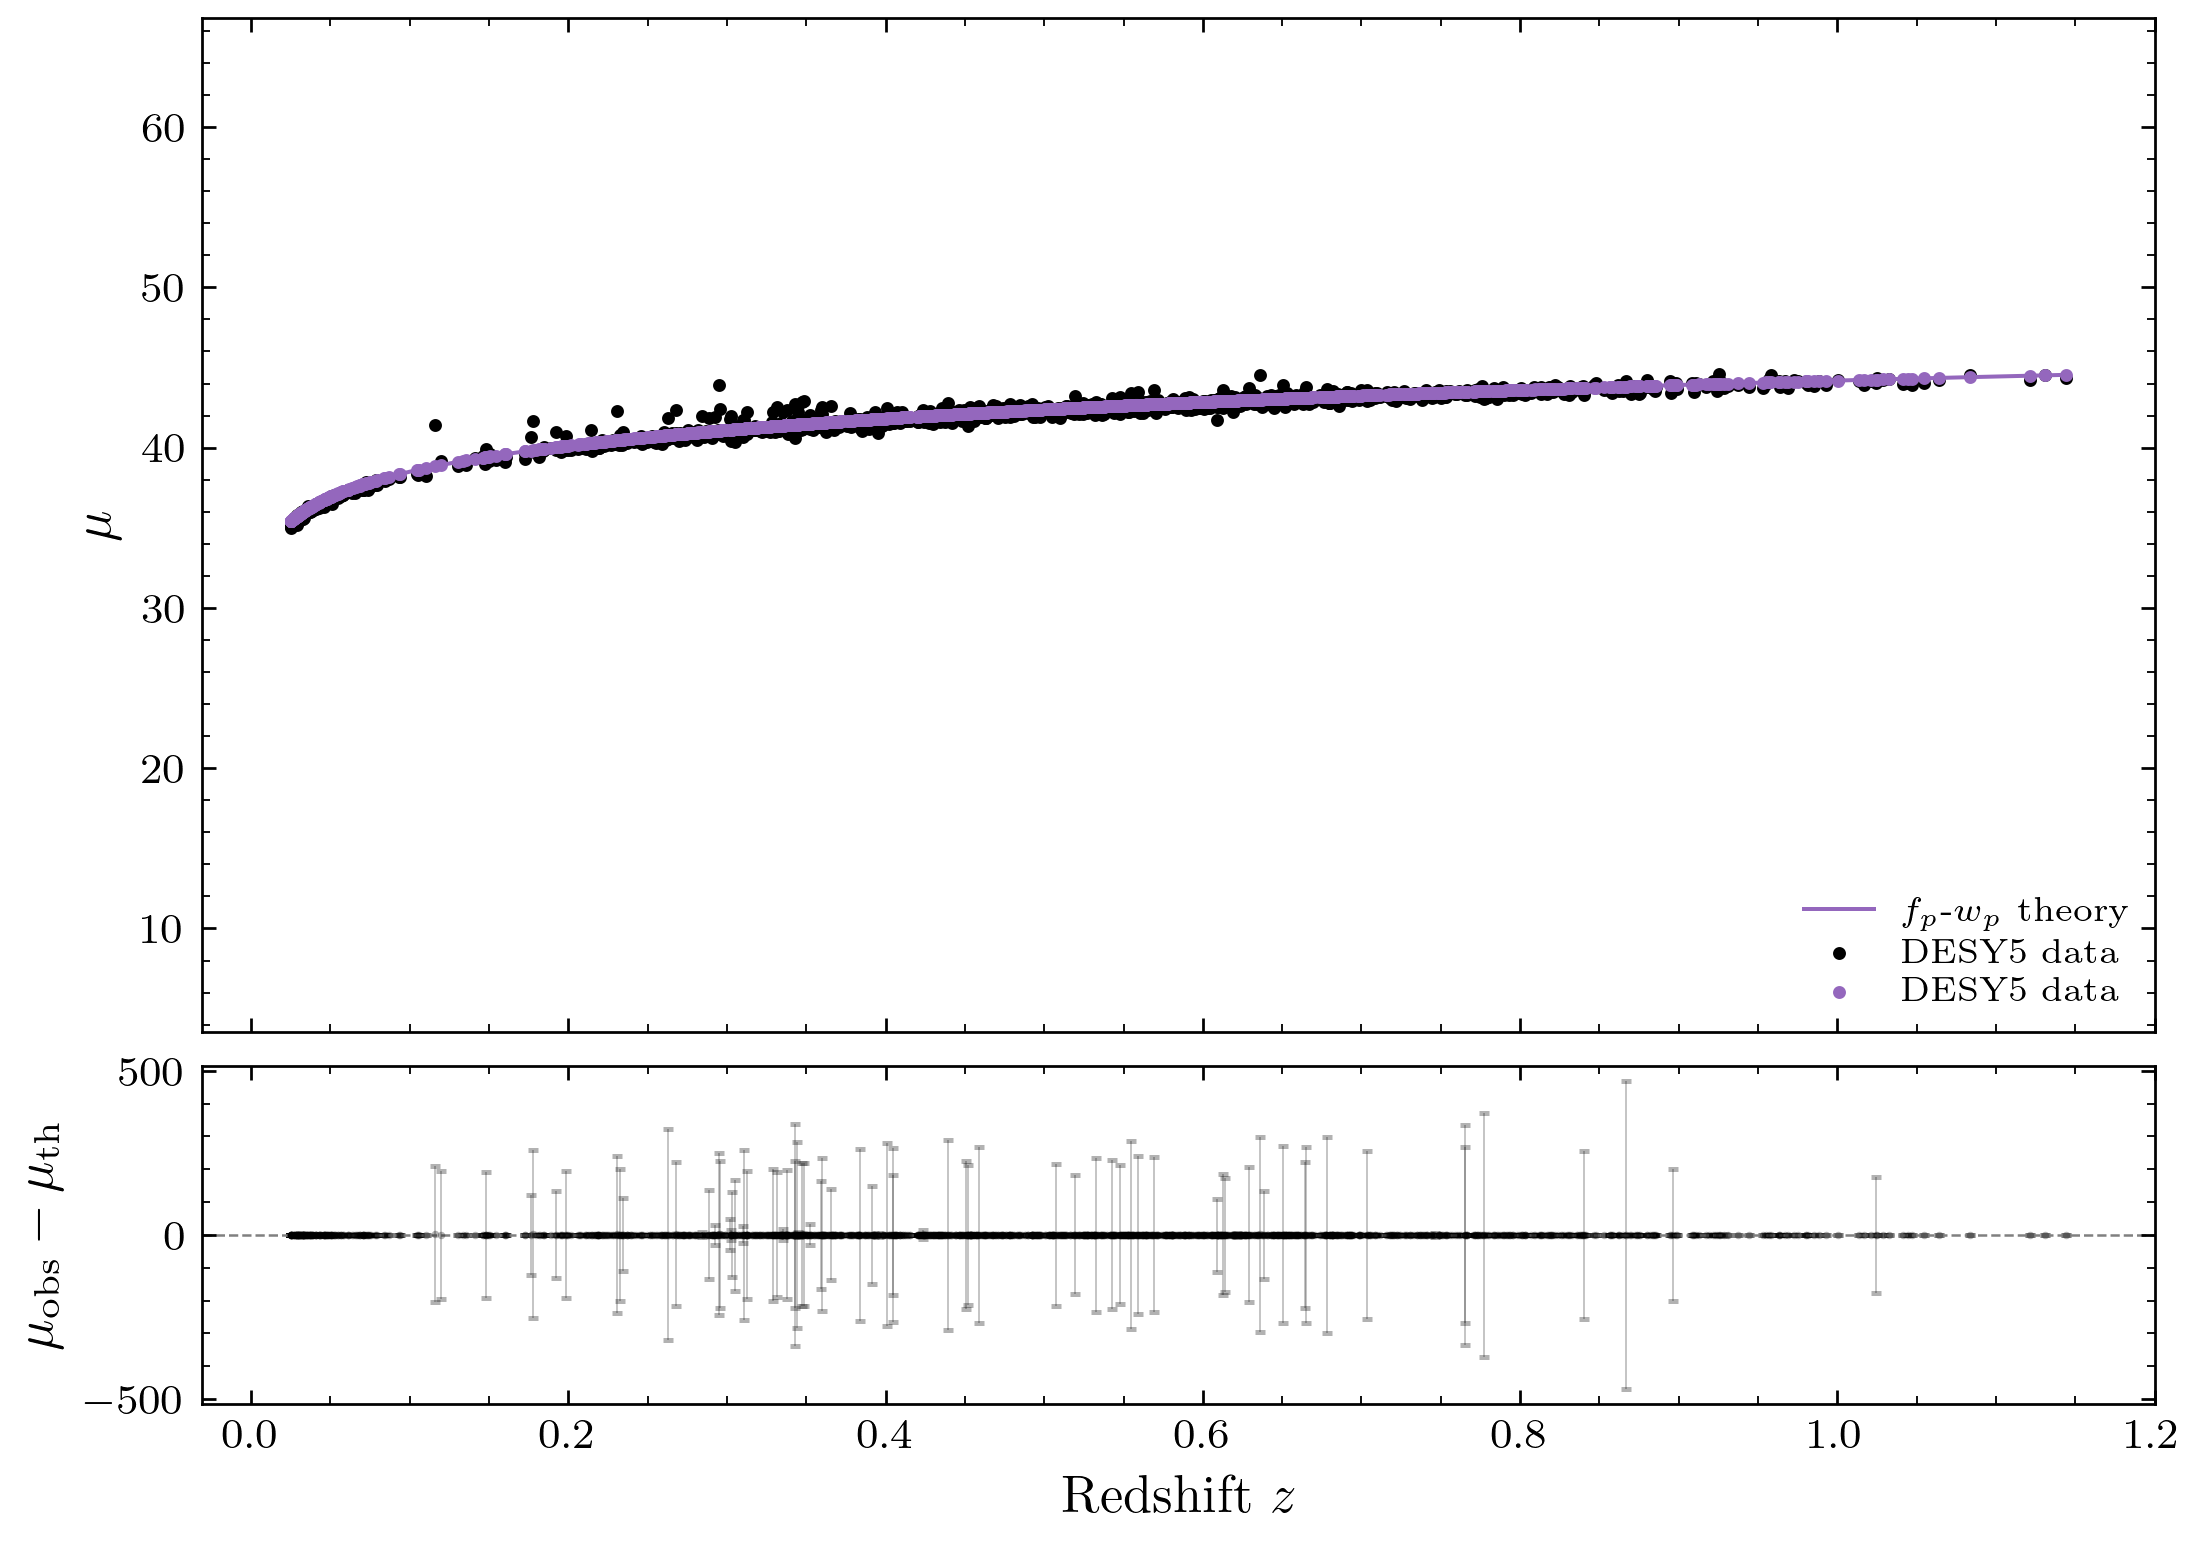

In [26]:
desy5like_fpwp = desy5_data.make_fake_DESY5_data(fpwpDE, mean_noise=False, return_theory=True)
plot_mock_sne(desy5_data, desy5like_fpwp, r'$f_p$-$w_p$', color='tab:purple')

## Generate mock likelihoods (SNe only + Qcmb)

In [ ]:
desy5_data.make_fake_likelihood(lcdm, 'lcdm', mean_noise=False)
desy5_data.make_fake_likelihood(expDE, 'exp', mean_noise=False)

## Generate combined mock likelihoods (BAO + SNe + Qcmb)
First create the BAO likelihoods from DESI data, then pass their names as `extra_lk` to the SNe likelihood generator.

In [42]:
# Load DESI BAO data
desiDR2_mean_file = "../data/desi_gaussian_bao_ALL_GCcomb_mean.txt"
desiDR2_cov_file = "../data/desi_gaussian_bao_ALL_GCcomb_cov.txt"
desiDR2_data = DESI_like_data(mean_file=desiDR2_mean_file, cov_file=desiDR2_cov_file)

In [ ]:
# Create BAO likelihoods first (without param files — we'll make joint ones via extra_lk)
bao_lcdm  = desiDR2_data.make_fake_likelihood(lcdm, 'lcdm', mean_noise=False)
bao_exp   = desiDR2_data.make_fake_likelihood(expDE, 'exp', mean_noise=False)

In [ ]:
# Create SNe likelihoods with BAO as extra_lk → param files will have BAO + SNe + Qcmb
desy5_data.make_fake_likelihood(lcdm, 'lcdm', mean_noise=False, extra_lk=bao_lcdm)
desy5_data.make_fake_likelihood(expDE, 'exp', mean_noise=False, extra_lk=bao_exp)

In [ ]:
desy5_data.make_fake_likelihood(expDEv2, 'exp', mean_noise=False)
bao_exp_v2   = desiDR2_data.make_fake_likelihood(expDEv2, 'exp', mean_noise=False)
desy5_data.make_fake_likelihood(expDEv2, 'exp', mean_noise=False, extra_lk=bao_exp_v2)